In [1]:
# imports

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data
import torchvision
import torchvision.transforms.v2 as tfs_v2
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
import torch.utils.data as data
from torchvision.transforms.v2 import InterpolationMode

In [2]:
import io
import os
from PIL import Image
import boto3
import torch.utils.data as data

class BrainSegmentation(data.Dataset):
    def __init__(
        self,
        path=None,
        bucket=None,
        prefix=None,
        transform_img=None,
        transform_mask=None,
    ):
        self.path = path
        self.bucket = bucket
        self.prefix = prefix.rstrip("/") if prefix else None
        self.transform_img = transform_img
        self.transform_mask = transform_mask

        self.s3 = None
        self.use_s3 = bucket is not None and prefix is not None

        if self.use_s3:
            self.s3 = boto3.client("s3")

            image_prefix = f"{self.prefix}/images/"
            mask_prefix = f"{self.prefix}/masks/"

            self.images = self._list_s3_keys(image_prefix)
            self.masks = self._list_s3_keys(mask_prefix)

            image_map = {
                os.path.basename(k): k
                for k in self.images
                if not k.endswith("/")
            }
            mask_map = {
                os.path.basename(k): k
                for k in self.masks
                if not k.endswith("/")
            }

            common_names = sorted(set(image_map.keys()) & set(mask_map.keys()))
            self.images = [image_map[name] for name in common_names]
            self.masks = [mask_map[name] for name in common_names]
            self.length = len(common_names)

        else:
            image_path = os.path.join(self.path, "images")
            mask_path = os.path.join(self.path, "masks")

            image_files = sorted(os.listdir(image_path))
            mask_files = sorted(os.listdir(mask_path))

            image_map = {
                filename: os.path.join(image_path, filename)
                for filename in image_files
            }
            mask_map = {
                filename: os.path.join(mask_path, filename)
                for filename in mask_files
            }

            common_names = sorted(set(image_map.keys()) & set(mask_map.keys()))
            self.images = [image_map[name] for name in common_names]
            self.masks = [mask_map[name] for name in common_names]
            self.length = len(common_names)

    def _list_s3_keys(self, prefix):
        keys = []
        paginator = self.s3.get_paginator("list_objects_v2")
        for page in paginator.paginate(Bucket=self.bucket, Prefix=prefix):
            for obj in page.get("Contents", []):
                key = obj["Key"]
                if not key.endswith("/"):
                    keys.append(key)
        return keys

    def _open_s3_image(self, key, mode):
        obj = self.s3.get_object(Bucket=self.bucket, Key=key)
        data_bytes = obj["Body"].read()
        return Image.open(io.BytesIO(data_bytes)).convert(mode)

    def __len__(self):
        return self.length

    def __getitem__(self, item):
        path_img, path_mask = self.images[item], self.masks[item]

        if self.use_s3:
            img = self._open_s3_image(path_img, "RGB")
            mask = self._open_s3_image(path_mask, "L")
        else:
            img = Image.open(path_img).convert("RGB")
            mask = Image.open(path_mask).convert("L")

        if self.transform_img:
            img = self.transform_img(img)

        if self.transform_mask:
            mask = self.transform_mask(mask)

        return img, mask


In [3]:

tr_img = tfs_v2.Compose([
    tfs_v2.Resize((256, 256), interpolation=InterpolationMode.BILINEAR), # resize images to reduce training
    tfs_v2.ToImage(),
    tfs_v2.ToDtype(torch.float32, scale=True)
])

tr_mask = tfs_v2.Compose([
    tfs_v2.Resize((256, 256), interpolation=InterpolationMode.NEAREST), # resize images to reduce training
    tfs_v2.ToImage(),
    tfs_v2.ToDtype(torch.float32),
    tfs_v2.Lambda(lambda x: (x >= 128).long())
])

dataset = BrainSegmentation(
    bucket="brain-data-bucket",
    prefix="brain_tumor_segmentation/raw",
    transform_img=tr_img,
    transform_mask=tr_mask,
)

img, mask = dataset[0]

print(img.dtype, img.min().item(), img.max().item())
print(img.shape, mask.shape)
print(mask.dtype, torch.unique(mask))

torch.float32 0.0 0.9568628072738647
torch.Size([3, 256, 256]) torch.Size([1, 256, 256])
torch.int64 tensor([0, 1])


In [4]:
img, mask = dataset[0]

print(img.dtype, img.min().item(), img.max().item())
print(img.shape, mask.shape)
print(mask.dtype, torch.unique(mask))

torch.float32 0.0 0.9568628072738647
torch.Size([3, 256, 256]) torch.Size([1, 256, 256])
torch.int64 tensor([0, 1])


torch.float32 0.0 0.9568628072738647
torch.Size([3, 256, 256]) torch.Size([1, 256, 256])
torch.int64 tensor([0, 1])


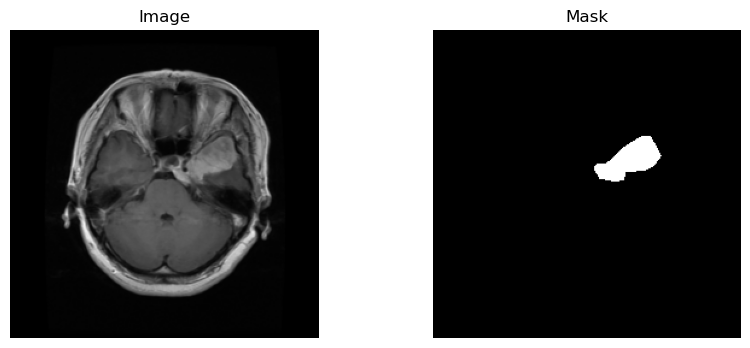

In [5]:
import matplotlib.pyplot as plt

img, mask = dataset[0]

print(img.dtype, img.min().item(), img.max().item())
print(img.shape, mask.shape)
print(mask.dtype, torch.unique(mask))

img_np = img.permute(1, 2, 0).cpu().numpy()
mask_np = mask.squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [6]:
# working with dataloader and first batch

train_data = data.DataLoader(dataset, batch_size=2, shuffle=True)

imgs, masks = next(iter(train_data))

print(imgs.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([2, 3, 256, 256])
torch.Size([2, 1, 256, 256])
tensor([0, 1])


In [7]:
# creating class which will describe our UNET network

class UnetModel(nn.Module):
    class _TwoConvLayers(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.model = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
            )

        def forward(self, x):
            return self.model(x)

    class _EncoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.block = UnetModel._TwoConvLayers(in_channels, out_channels)
            self.max_pool = nn.MaxPool2d(2)

        def forward(self, x):
            x = self.block(x)
            y = self.max_pool(x)
            return y, x

    class _DecoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.transpose = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
            self.block = UnetModel._TwoConvLayers(in_channels, out_channels)

        def forward(self, x, y):
            x = self.transpose(x)
            u = torch.cat([x, y], dim=1)
            u = self.block(u)

            return u

    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()
        self.enc_block1 = self._EncoderBlock(in_channels, 64)
        self.enc_block2 = self._EncoderBlock(64, 128)
        self.enc_block3 = self._EncoderBlock(128, 256)
        self.enc_block4 = self._EncoderBlock(256, 512)

        self.bottleneck = self._TwoConvLayers(512, 1024)

        self.dec_block1 = self._DecoderBlock(1024, 512)
        self.dec_block2 = self._DecoderBlock(512, 256)
        self.dec_block3 = self._DecoderBlock(256, 128)
        self.dec_block4 = self._DecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self,x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)


In [8]:
# split into train and val datasets

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(train_dataset.__len__())
print(val_dataset.__len__())

2451
613


In [15]:
#creating of two dataloaders

train_dataloader = data.DataLoader(train_dataset, batch_size=6, shuffle=True, num_workers=0)
val_dataloader = data.DataLoader(val_dataset, batch_size=6, shuffle=False, num_workers=0)

In [16]:
# creating additional class for loss

class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num = targets.size(0)
        probs = nn.functional.sigmoid(logits)
        m1 = probs.view(num, -1)
        m2 = targets.view(num, -1)
        intersection = (m1 * m2)

        score = 2 * (intersection.sum(1) + self.smooth) / (m1.sum(1) + m2.sum(1) + self.smooth)
        score = 1 - score.sum() / num
        return score

In [17]:
# creating of model, optimizer and loss functions

model = UnetModel()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

loss_1 = nn.BCEWithLogitsLoss()
loss_2 = SoftDiceLoss()

In [18]:
# function just for metrics
# logits - prediction from model
# targets - true values

def dice_score(logits, targets, eps=1e-4):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * intersection + eps) / (union + eps)
    
    return dice.mean().item()


In [19]:
# working with validation dataset

def validate(model, val_dataloader, loss_1, loss_2, device):
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    count = 0

    with torch.no_grad():
        for imgs, masks in val_dataloader:
            imgs = imgs.to(device)
            masks = masks.float().to(device)

            preds = model(imgs)
            loss = loss_1(preds, masks) + loss_2(preds, masks)

            val_loss += loss.item()
            val_dice += dice_score(preds, masks)
            count += 1

    return val_loss / count, val_dice / count

In [ ]:
# training of our model
# each epoch we will predict on validation dataset, calculate loss and diss for this dataset
# we will save the best result from validatation dataset to 'best_model.tar' file
# from this file 'best_model.tar' we will get the data to plot the result

epochs = 2
log_interval = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

best_dice = -1.0

for _e in range(epochs):
    print(f"epoch {_e}")
    
    model.train()
    
    loss_mean = 0
    lm_count = 0

    for batch_idx, (imgs, masks) in enumerate(train_dataloader):
        print(f"batch {batch_idx}")
        
        imgs, masks = imgs.to(device), masks.to(device)
        
        masks = masks.float()

        predict = model(imgs)
        loss = loss_1(predict, masks) + loss_2(predict, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean += loss.item()

        if (batch_idx + 1) % log_interval == 0:
            print(f"Epoch [{_e+1}/{epochs}] | Batch [{batch_idx+1}/{len(train_dataloader)}] | Train loss: {loss_mean / lm_count:.4f}")

    #validation
    val_loss, val_dice = validate(model, val_dataloader, loss_1, loss_2, device)

    print(f"Epoch {_e+1}: " f"val_loss = {val_loss:.4f}, val_dice = {val_dice:.4f}")

    # save best result
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(
            {
                "epoch": _e + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_dice": best_dice,
            },
            "best_model.tar",
        )
        
        print(f"best model saved (dice = {best_dice:.4f})")

epoch 0
batch 0
batch 1


## get data from 'best_model.tar' file
chekpoint = torch.load('best_model.tar',map_location=device)
model.load_state_dict(chekpoint["model_state"])

model.to(device)
model.eval()

print("Loaded epoch:", chekpoint.get("epoch"), "best_dice:", chekpoint.get("best_dice"))

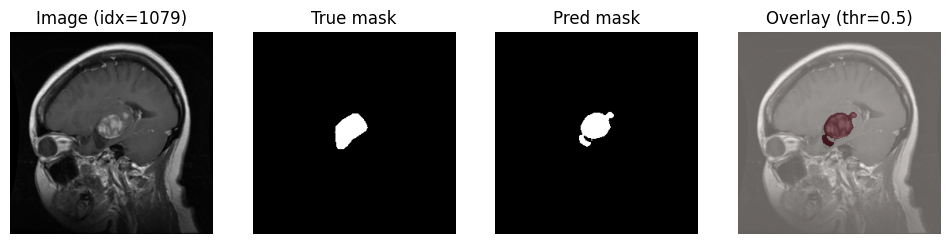

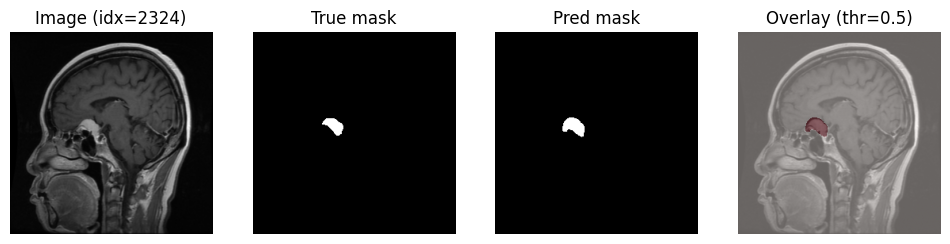

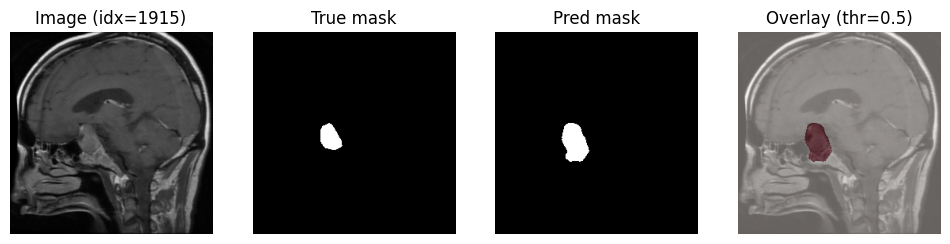

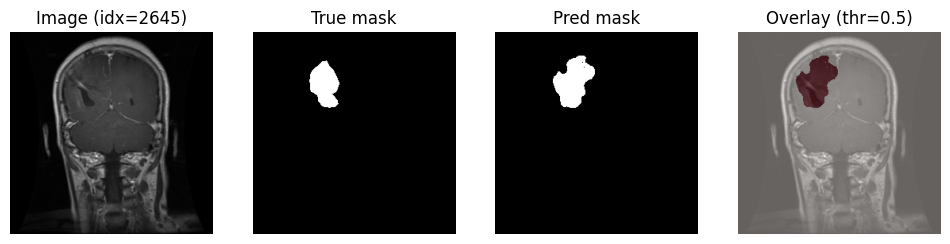

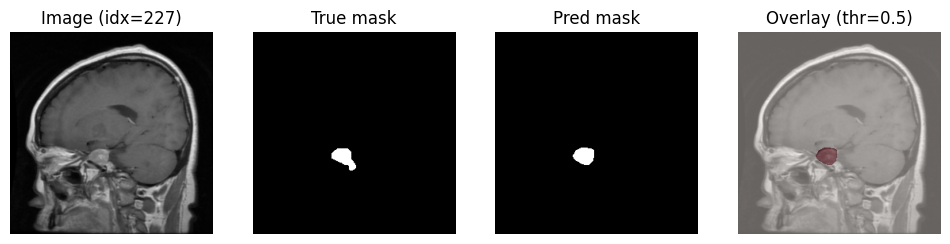

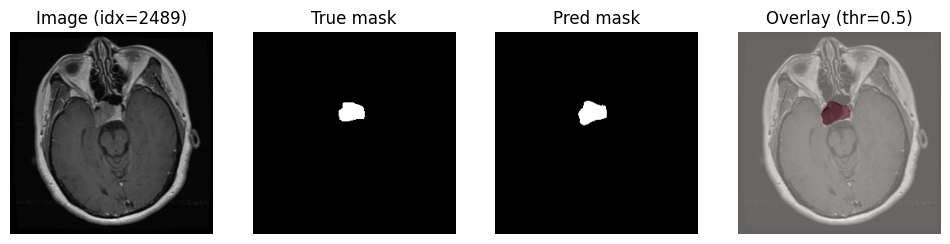

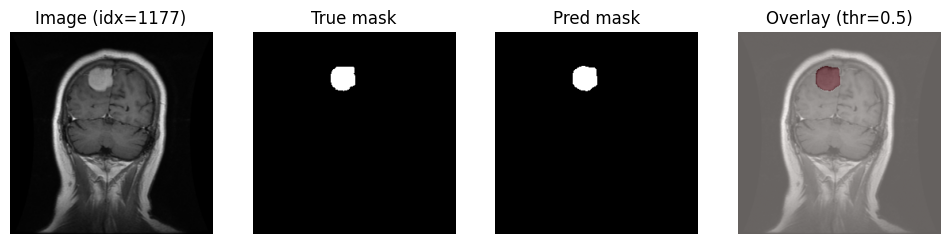

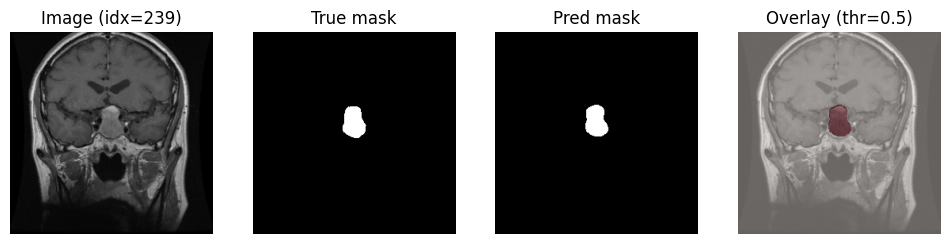

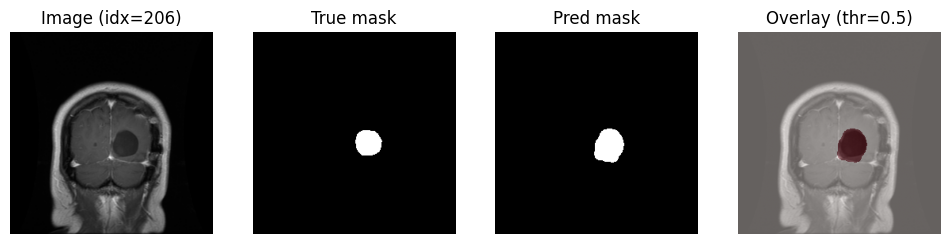

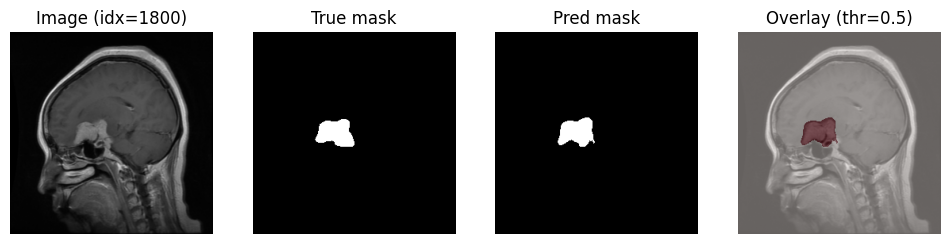

In [152]:
# visualize the result
import random

model.eval()

#indices = list(range(max(5, len(val_dataset))))
indices = random.sample(range(len(dataset)), k=10)

with torch.no_grad():
    for idx in indices:
        # get an image and mask from dataset
        img, true_mask = dataset[idx]

        #create batch from image and mask
        img_batch = img.unsqueeze(0).to(device)
        true_mask_batch = true_mask.unsqueeze(0).to(device)

        logits = model(img_batch) # in result we will have logits (it's like prediction of model)

        probs = torch.sigmoid(logits) # convert all values in [1,1,H,W] to [0..1]

        #make decision
        pred_mask = (probs > 0.5).float()

        #data for matplotlib
        img_np = img.permute(1, 2, 0).cpu().numpy() #image
        true_np = true_mask.squeeze(0).cpu().numpy() #true mask
        pred_np = pred_mask.squeeze(0).squeeze(0).cpu().numpy() #predicted mask
        prob_np = probs.squeeze(0).squeeze(0).cpu().numpy() 

        #plotting
        plt.figure(figsize=(12, 3))

        plt.subplot(1, 4, 1)
        plt.title(f"Image (idx={idx})")
        plt.imshow(img_np)
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title("True mask")
        plt.imshow(true_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title("Pred mask")
        plt.imshow(pred_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title(f"Overlay (thr={0.5})")
        plt.imshow(img_np)
        plt.imshow(pred_np, alpha=0.4, cmap="Reds")  # красным поверх картинки
        plt.axis("off")

        plt.show()